In [5]:
from diffusers.utils.import_utils import is_xformers_available
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from tqdm.auto import tqdm
import torchvision
from transformers import AutoTokenizer, PretrainedConfig
from transformers.models.clip.modeling_clip import CLIPVisionModelWithProjection
import numpy as np
import pdb; 
from ip_adapter.resampler import Resampler
import random

ModuleNotFoundError: No module named 'ip_adapter'

In [1]:

import torchvision.transforms as transforms

import torch
import torch.nn as nn
from transformers.models.clip.configuration_clip import CLIPVisionConfig
from transformers.models.clip.modeling_clip import CLIPVisionModelWithProjection

VISION_CONFIG_DICT = {
    "hidden_size": 1024,
    "intermediate_size": 4096,
    "num_attention_heads": 16,
    "num_hidden_layers": 24,
    "patch_size": 14,
    "projection_dim": 768
}

class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim, use_residual=True):
        super().__init__()
        if use_residual:
            assert in_dim == out_dim
        self.layernorm = nn.LayerNorm(in_dim)
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_dim)
        self.use_residual = use_residual
        self.act_fn = nn.GELU()

    def forward(self, x):
        residual = x
        x = self.layernorm(x)
        x = self.fc1(x)
        x = self.act_fn(x)
        x = self.fc2(x)
        if self.use_residual:
            x = x + residual
        return x


class FuseModule(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.mlp1 = MLP(embed_dim * 2, embed_dim, embed_dim, use_residual=False)
        self.mlp2 = MLP(embed_dim, embed_dim, embed_dim, use_residual=True)
        self.layer_norm = nn.LayerNorm(embed_dim)

    def fuse_fn(self, prompt_embeds, id_embeds):
        stacked_id_embeds = torch.cat([prompt_embeds, id_embeds], dim=-1)
        stacked_id_embeds = self.mlp1(stacked_id_embeds) + prompt_embeds
        stacked_id_embeds = self.mlp2(stacked_id_embeds)
        stacked_id_embeds = self.layer_norm(stacked_id_embeds)
        return stacked_id_embeds

    def forward(
        self,
        prompt_embeds,
        id_embeds,
        class_tokens_mask,
    ) -> torch.Tensor:
        # id_embeds shape: [b, max_num_inputs, 1, 2048]
        id_embeds = id_embeds.to(prompt_embeds.dtype)
        num_inputs = class_tokens_mask.sum().unsqueeze(0) # TODO: check for training case
        batch_size, max_num_inputs = id_embeds.shape[:2]
        # seq_length: 77
        seq_length = prompt_embeds.shape[1]
        # flat_id_embeds shape: [b*max_num_inputs, 1, 2048]
        flat_id_embeds = id_embeds.view(
            -1, id_embeds.shape[-2], id_embeds.shape[-1]
        )
        # valid_id_mask [b*max_num_inputs]
        valid_id_mask = (
            torch.arange(max_num_inputs, device=flat_id_embeds.device)[None, :]
            < num_inputs[:, None]
        )
        valid_id_embeds = flat_id_embeds[valid_id_mask.flatten()]

        prompt_embeds = prompt_embeds.view(-1, prompt_embeds.shape[-1])
        class_tokens_mask = class_tokens_mask.view(-1)
        valid_id_embeds = valid_id_embeds.view(-1, valid_id_embeds.shape[-1])
        # slice out the image token embeddings
        image_token_embeds = prompt_embeds[class_tokens_mask]
        stacked_id_embeds = self.fuse_fn(image_token_embeds, valid_id_embeds)
        assert class_tokens_mask.sum() == stacked_id_embeds.shape[0], f"{class_tokens_mask.sum()} != {stacked_id_embeds.shape[0]}"
        prompt_embeds.masked_scatter_(class_tokens_mask[:, None], stacked_id_embeds.to(prompt_embeds.dtype))
        updated_prompt_embeds = prompt_embeds.view(batch_size, seq_length, -1)
        return updated_prompt_embeds

# modified ID Encoder of PhotoMaker, batch size dimension is ignored and default to 1, the fuse module is ignored
class PhotoMakerIDEncoder(CLIPVisionModelWithProjection):
    def __init__(self):
        super().__init__(CLIPVisionConfig(**VISION_CONFIG_DICT))
        self.visual_projection_2 = nn.Linear(1024, 1280, bias=False)
        self.fuse_module = FuseModule(2048)

    def forward(self, id_pixel_values):
        num_inputs, c, h, w = id_pixel_values.shape
        id_pixel_values = id_pixel_values.view(num_inputs, c, h, w)

        shared_id_embeds = self.vision_model(id_pixel_values)[1]
        id_embeds = self.visual_projection(shared_id_embeds)
        id_embeds_2 = self.visual_projection_2(shared_id_embeds)

        id_embeds = id_embeds.view(num_inputs, 1, -1)
        id_embeds_2 = id_embeds_2.view(num_inputs, 1, -1)

        id_embeds = torch.cat((id_embeds, id_embeds_2), dim=-1)

        return id_embeds

/data1/humw/anaconda3/envs/photomaker/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# 加载CLIP
import copy
import hashlib
import itertools
import logging
import os
from pathlib import Path

import datasets
import diffusers
import torch
import torch.nn.functional as F
import torch.utils.checkpoint
import transformers
from accelerate import Accelerator
from accelerate.logging import get_logger
from accelerate.utils import set_seed
from diffusers import AutoencoderKL, DDPMScheduler, DiffusionPipeline, UNet2DConditionModel

torch_dtype = torch.float16
model_type_list = ["vae15", "ipadapter", "photomaker"]
device = "cuda:3"
model_dict = dict()
for model_type in model_type_list:
    if "vae14" == model_type: # 加载VAE模型
        model = AutoencoderKL.from_pretrained(
            pretrained_model_name_or_path="/data1/humw/Pretrains/stable-diffusion-v1-4", 
            subfolder="vae",
        ).to(dtype=torch_dtype).eval().requires_grad_(False)
    elif "vae15" == model_type: # 加载VAE模型
        model = AutoencoderKL.from_pretrained(
            pretrained_model_name_or_path="/data1/humw/Pretrains/stable-diffusion-v1-5", 
            subfolder="vae", 
        ).to(dtype=torch_dtype).eval().requires_grad_(False)
    elif "vae21" == model_type: # 加载VAE模型
        model = AutoencoderKL.from_pretrained(
            pretrained_model_name_or_path="/data1/humw/Pretrains/stable-diffusion-2-1-base", 
            subfolder="vae", 
        ).to(dtype=torch_dtype).eval().requires_grad_(False)
    elif model_type == "ipadapter":
        ipadapter_path = "/data1/humw/Pretrains/IP-Adapter/models/image_encoder"
        model = CLIPVisionModelWithProjection.from_pretrained(ipadapter_path).to(dtype=torch_dtype).eval().requires_grad_(False)
    elif model_type == "photomaker":
        model = PhotoMakerIDEncoder()
        state_dict = torch.load("/data1/humw/Pretrains/photomaker-v1.bin", map_location="cpu")
        model.load_state_dict(state_dict['id_encoder'], strict=True)
        model.to(dtype=torch_dtype).eval().requires_grad_(False)
    model_dict[model_type] = model.to(device)

/data1/humw/anaconda3/envs/photomaker/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/tmp/ipykernel_3784040/16991515.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you

In [3]:
def load_data(data_dir="", size=512, center_crop=True) -> torch.Tensor:
    def image_to_numpy(image):
        return np.array(image).astype(np.uint8)
    # more robust loading to avoid loaing non-image files
    images = [] 
    for i in list(Path(data_dir).iterdir()):
        if not i.suffix in [".jpg", ".png", ".jpeg"]:
            continue
        else:
            images.append(image_to_numpy(Image.open(i).convert("RGB")))
    images = [Image.fromarray(i).resize((size, size), 2) for i in images]
    images = np.stack(images)
    # from B x H x W x C to B x C x H x W
    images = torch.from_numpy(images).permute(0, 3, 1, 2).float()
    assert images.shape[-1] == images.shape[-2]
    return images

In [8]:
original_image_dir = "/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/VGGFace2/n000050/set_B"
ted_image_dir = "/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/Encoder_attack_conda-photomaker_VGGFace2_vae15-ipadapter-photomaker_mix_eot-0_yingbu_agm-2_norm-0/n000050"
vae_image_dir = "/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/Encoder_attack_conda-photomaker_VGGFace2_vae15_mse_eot-0_yingbu_agm-0_norm-0/n000050"
ipadapter_image_dir = "/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/Encoder_attack_conda-photomaker_VGGFace2_ipadapter_mix_eot-0_yingbu_agm-0_norm-0/n000050"
photomaker_image_dir = "/data1/humw/Codes/My-Anti-DreamBooth/outputs/adversarial_images/Encoder_attack_conda-photomaker_VGGFace2_photomaker_cosine_eot-0_yingbu_agm-0_norm-0/n000050"

original_image_data = load_data(data_dir=original_image_dir)
ted_image_data = load_data(data_dir=ted_image_dir)
vae_image_data = load_data(data_dir=vae_image_dir)
ipadapter_image_data = load_data(data_dir=ipadapter_image_dir)
photomaker_image_data = load_data(data_dir=photomaker_image_dir)

resample_interpolation = transforms.InterpolationMode.BILINEAR

train_aug_224 = [
    transforms.Resize(224, interpolation=resample_interpolation),
    transforms.CenterCrop(224),
]
tensorize_and_normalize = [
    transforms.Normalize([0.5*255]*3,[0.5*255]*3),
]
trans_224 = train_aug_224 + tensorize_and_normalize
trans_224 = transforms.Compose(trans_224)

train_aug_512 = [
    transforms.Resize(512, interpolation=resample_interpolation),
    transforms.CenterCrop(512),
]
trans_512 = train_aug_512 + tensorize_and_normalize
trans_512 = transforms.Compose(trans_512)

In [ ]:
# 获取原始图像编码

tran_original_data_512 = trans_512(original_image_data).to(device).to(torch_dtype)
vae_ori_image_embeds = model_dict["vae15"].encode(tran_original_data_512).latent_dist.sample() * model_dict["vae15"].config.scaling_factor
tran_original_data_224 = trans_224(original_image_data).to(device).to(torch_dtype)
ipadapter_ori_image_embeds = model_dict["ipadapter"](tran_original_data_224, output_hidden_states=True).hidden_states[-2]
photomaker_ori_image_embeds = model_dict["photomaker"](tran_original_data_224)

In [11]:
# 获取TED图像编码

tran_ted_data_512 = trans_512(ted_image_data).to(device).to(torch_dtype)
vae_ted_image_embeds = model_dict["vae15"].encode(tran_ted_data_512).latent_dist.sample() * model_dict["vae15"].config.scaling_factor
tran_ted_data_224 = trans_224(ted_image_data).to(device).to(torch_dtype)
ipadapter_ted_image_embeds = model_dict["ipadapter"](tran_ted_data_224, output_hidden_states=True).hidden_states[-2]
photomaker_ted_image_embeds = model_dict["photomaker"](tran_ted_data_224)

In [12]:
# 获取仅扰动vae的图像编码

tran_vae_data_512 = trans_512(vae_image_data).to(device).to(torch_dtype)
vae_vae_image_embeds = model_dict["vae15"].encode(tran_vae_data_512).latent_dist.sample() * model_dict["vae15"].config.scaling_factor
tran_vae_data_224 = trans_224(vae_image_data).to(device).to(torch_dtype)
ipadapter_vae_image_embeds = model_dict["ipadapter"](tran_vae_data_224, output_hidden_states=True).hidden_states[-2]
photomaker_vae_image_embeds = model_dict["photomaker"](tran_vae_data_224)

In [13]:
# 获取仅扰动ipadapter的图像编码

tran_ipadapter_data_512 = trans_512(ipadapter_image_data).to(device).to(torch_dtype)
vae_ipadapter_image_embeds = model_dict["vae15"].encode(tran_ipadapter_data_512).latent_dist.sample() * model_dict["vae15"].config.scaling_factor
tran_ipadapter_data_224 = trans_224(ipadapter_image_data).to(device).to(torch_dtype)
ipadapter_ipadapter_image_embeds = model_dict["ipadapter"](tran_ipadapter_data_224, output_hidden_states=True).hidden_states[-2]
photomaker_ipadapter_image_embeds = model_dict["photomaker"](tran_ipadapter_data_224)

In [14]:
# 获取仅扰动photomaker的图像编码

tran_photomaker_data_512 = trans_512(photomaker_image_data).to(device).to(torch_dtype)
vae_photomaker_image_embeds = model_dict["vae15"].encode(tran_photomaker_data_512).latent_dist.sample() * model_dict["vae15"].config.scaling_factor
tran_photomaker_data_224 = trans_224(photomaker_image_data).to(device).to(torch_dtype)
ipadapter_photomaker_image_embeds = model_dict["ipadapter"](tran_photomaker_data_224, output_hidden_states=True).hidden_states[-2]
photomaker_photomaker_image_embeds = model_dict["photomaker"](tran_photomaker_data_224)

In [18]:
vae_embeds_list = [vae_ori_image_embeds, vae_ted_image_embeds, vae_vae_image_embeds, vae_ipadapter_image_embeds, vae_photomaker_image_embeds]
ipadapter_embeds_list = [ipadapter_ori_image_embeds, ipadapter_ted_image_embeds, ipadapter_vae_image_embeds, ipadapter_ipadapter_image_embeds, ipadapter_photomaker_image_embeds]
photomaker_embeds_list = [photomaker_ori_image_embeds, photomaker_ted_image_embeds, photomaker_vae_image_embeds, photomaker_ipadapter_image_embeds, photomaker_photomaker_image_embeds]

In [21]:
import torch.nn.functional as F

weight_dtype = torch.float16
dist_list = list() # 存储ori与ted、vae ipadapter、photomaker编码之间的距离，每个原始是list，存储vae、ipadapter、photomaker编码距离
for i in range(1, len(vae_embeds_list)):
    # 计算原始图像与TED保护后图像之间的距离
    # vae编码，mse距离，越大越好
    mse_vae_ori = F.mse_loss(vae_embeds_list[0].to(weight_dtype), vae_embeds_list[i].to(weight_dtype), reduction="mean").item()
    # ipadapter编码，cosine距离，越大越好
    cosine_ipadapter_ori = 1 - F.cosine_similarity(ipadapter_embeds_list[0].to(weight_dtype), ipadapter_embeds_list[i].to(weight_dtype), -1).mean().item()
    # photomaker编码，cosine距离，越大越好
    cosine_photomaker_ori = 1 - F.cosine_similarity(photomaker_embeds_list[0].to(weight_dtype), photomaker_embeds_list[i].to(weight_dtype), -1).mean().item()
    tmp = [mse_vae_ori, cosine_ipadapter_ori, cosine_photomaker_ori]
    dist_list.append(tmp)


In [22]:
dist_list

[[0.56787109375, 0.643310546875, 0.89801025390625],
 [0.5849609375, 0.32861328125, 0.07470703125],
 [0.327880859375, 0.8114013671875, 0.19091796875],
 [0.270263671875, 0.3837890625, 0.960784912109375]]

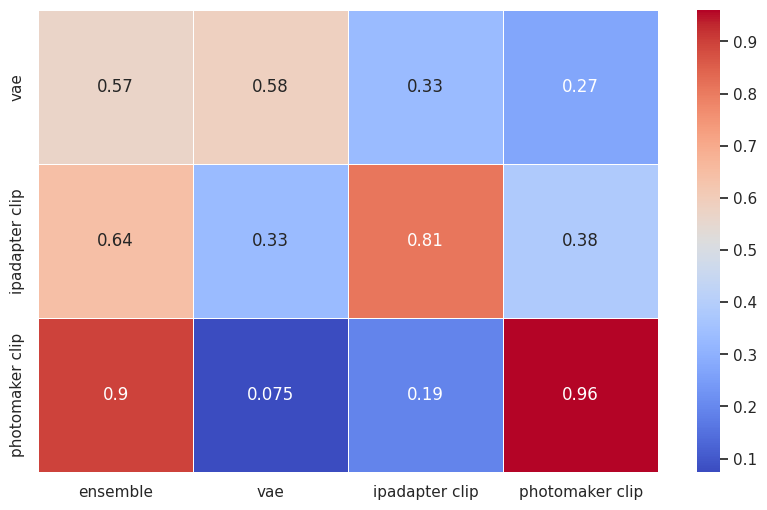

In [28]:
# 绘制热力图，纵向从上往下分别为ensemble，vae，ipadapter clip，photomaker clip，从左往右依次为vae，ipadapter clip，photomaker clip
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 假定你已经有了数据，这里我们创建一个示例DataFrame来模拟你的数据
data = {
    'ensemble': [0.56787109375, 0.643310546875, 0.89801025390625],
    'vae': [0.5849609375, 0.32861328125, 0.07470703125],
    'ipadapter_clip': [0.327880859375, 0.8114013671875, 0.19091796875],
    'photomaker_clip': [0.270263671875, 0.3837890625, 0.960784912109375]
}
df = pd.DataFrame(data)

# 设置绘图样式
sns.set(style="white")

# 使用seaborn的heatmap函数绘制热力图
plt.figure(figsize=(10, 6))
ax = sns.heatmap(df, annot=True, cmap='coolwarm', linewidths=.5)  # 这里使用'coolwarm'颜色映射

# 设置x轴和y轴标签
ax.set_yticklabels(['vae', 'ipadapter clip', 'photomaker clip'])
ax.set_xticklabels(['ensemble', 'vae', 'ipadapter clip', 'photomaker clip'])
plt.show()